In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
master = pd.read_csv(
    "../processed/master_features.csv"
)

print(master.shape)

master.head()

C:\Users\shubh\AppData\Local\Temp\ipykernel_33324\742052704.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(


(2149071, 13)


,start_time,station_id,location_type,energy_delivered,session_duration_hr,charging_time_hr,utilization_rate,revenue,queue_proxy,hour,day_of_week,month,is_weekend
0,2018-04-25 11:08:04,2-39-78-362,workplace,7.932,2.201667,2.218333,0.092431,118.980,2,11.0,Wednesday,4.0,0
1,2018-04-25 13:45:10,2-39-95-27,workplace,10.013,11.185000,2.984722,0.124363,150.195,46,13.0,Wednesday,4.0,0
2,2018-04-25 13:45:50,2-39-79-380,workplace,5.257,9.315278,1.098333,0.045764,78.855,81,13.0,Wednesday,4.0,0
3,2018-04-25 14:37:06,2-39-79-379,workplace,5.177,9.307778,1.471111,0.061296,77.655,38,14.0,Wednesday,4.0,0
4,2018-04-25 14:40:34,2-39-79-381,workplace,10.119,8.377222,2.998889,0.124954,151.785,52,14.0,Wednesday,4.0,0


In [3]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149071 entries, 0 to 2149070
Data columns (total 13 columns):
 #   Column               Dtype  
---  ------               -----  
 0   start_time           object 
 1   station_id           object 
 2   location_type        object 
 3   energy_delivered     float64
 4   session_duration_hr  float64
 5   charging_time_hr     float64
 6   utilization_rate     float64
 7   revenue              float64
 8   queue_proxy          int64  
 9   hour                 float64
 10  day_of_week          object 
 11  month                float64
 12  is_weekend           int64  
dtypes: float64(7), int64(2), object(4)
memory usage: 213.1+ MB


In [4]:
master.describe()

,energy_delivered,session_duration_hr,charging_time_hr,utilization_rate,revenue,queue_proxy,hour,month,is_weekend
count,2.149071e+06,2.149071e+06,14991.000000,2.149071e+06,2.149071e+06,2.149071e+06,2.149071e+06,2.149071e+06,2.149071e+06
mean,3.648541e+01,1.503697e+00,3.236411,9.979489e-02,3.073036e+01,2.198497e+01,1.151156e+01,6.610405e+00,2.992084e-01
std,1.015653e+02,1.912299e+00,3.185251,1.128197e-01,7.409952e+01,2.481624e+01,6.923724e+00,5.318513e-01,4.579114e-01
min,0.000000e+00,0.000000e+00,-0.689444,-2.872685e-02,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00
25%,2.333333e+00,3.333333e-01,1.271806,2.272727e-02,2.295417e+00,5.000000e+00,6.000000e+00,6.000000e+00,0.000000e+00
50%,7.000000e+00,8.333333e-01,2.241667,5.909091e-02,6.878375e+00,1.300000e+01,1.200000e+01,7.000000e+00,0.000000e+00
75%,2.316667e+01,1.916667e+00,4.244444,1.363636e-01,2.216000e+01,3.000000e+01,1.800000e+01,7.000000e+00,1.000000e+00
max,1.492500e+03,2.452692e+02,104.428333,1.000000e+00,1.040595e+03,2.200000e+02,2.300000e+01,1.200000e+01,1.000000e+00


In [5]:
master.isnull().sum()

start_time                   0
station_id                   0
location_type                0
energy_delivered             0
session_duration_hr          0
charging_time_hr       2134080
utilization_rate             0
revenue                      0
queue_proxy                  0
hour                         0
day_of_week                  0
month                        0
is_weekend                   0
dtype: int64

In [6]:
hourly_demand = (
    master.groupby("hour")
    ["energy_delivered"]
    .mean()
)

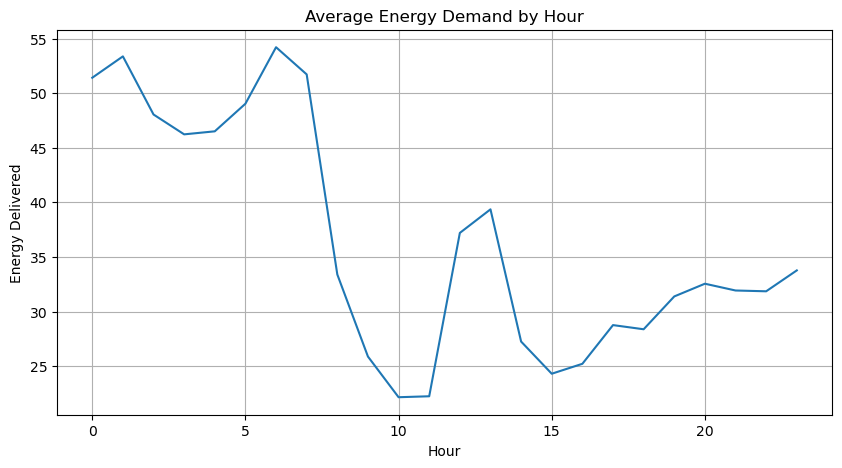

In [7]:
plt.figure(figsize=(10,5))

hourly_demand.plot()

plt.title("Average Energy Demand by Hour")

plt.xlabel("Hour")

plt.ylabel("Energy Delivered")

plt.grid(True)

plt.show()

Charging demand exhibits strong temporal variation. The highest average energy demand is observed during the early morning hours (approximately 1 AM and 6–7 AM), exceeding 50 kWh per charging interval. Demand falls significantly during late morning hours (10–11 AM), where average energy delivered drops below 25 kWh. This suggests clear opportunities for dynamic tariff optimization, with premium pricing during high-demand periods and discount incentives during low-demand intervals.

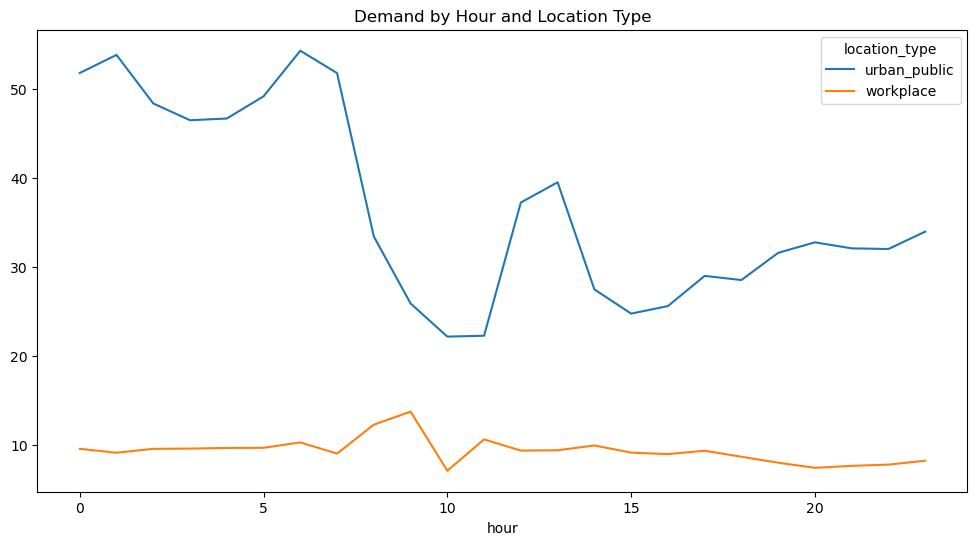

In [8]:
master.groupby(
    ["location_type","hour"]
)["energy_delivered"].mean().unstack(0).plot(
    figsize=(12,6)
)

plt.title("Demand by Hour and Location Type")
plt.show()

Workplace charging exhibits morning peaks, while urban public charging demonstrates a more distributed demand profile.

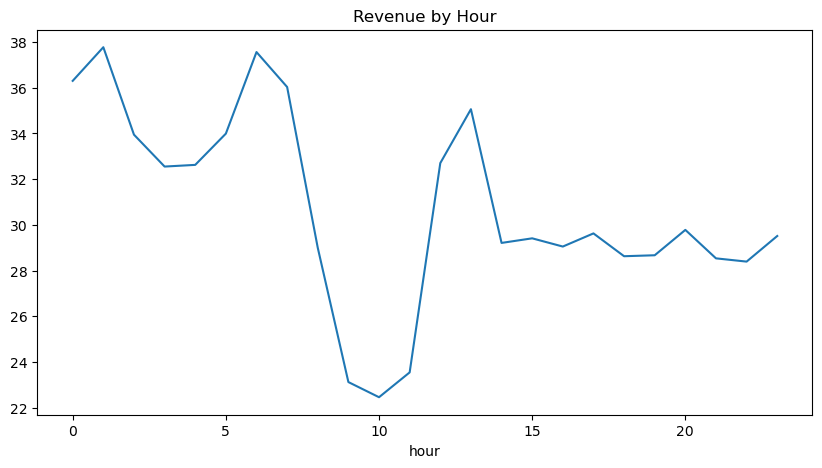

In [9]:
hourly_revenue = (
    master.groupby("hour")["revenue"]
    .mean()
)

hourly_revenue.plot(figsize=(10,5))
plt.title("Revenue by Hour")
plt.show()

Revenue follows the same temporal pattern as charging demand, with maximum revenue generation occurring during early-morning charging windows and minimum revenue during late-morning periods. The observed 40% revenue gap between peak and off-peak intervals demonstrates substantial opportunity for dynamic tariff optimization through demand shaping and load redistribution.

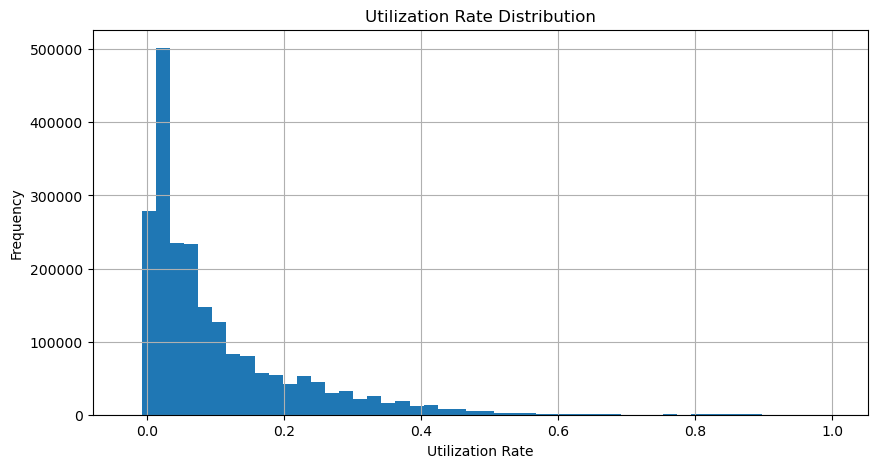

In [10]:
plt.figure(figsize=(10,5))

master["utilization_rate"].hist(
    bins=50
)

plt.title(
    "Utilization Rate Distribution"
)

plt.xlabel("Utilization Rate")

plt.ylabel("Frequency")

plt.show()

More than half of charging observations occur at utilization levels below 20%, indicating substantial underutilization of charging infrastructure and creating an opportunity for discount-based demand stimulation.

In [11]:
master["utilization_rate"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95]
)

count    2.149071e+06
mean     9.979489e-02
std      1.128197e-01
min     -2.872685e-02
25%      2.272727e-02
50%      5.909091e-02
75%      1.363636e-01
90%      2.590909e-01
95%      3.409091e-01
max      1.000000e+00
Name: utilization_rate, dtype: float64

Analysis of charger utilization reveals substantial excess capacity across the network. The median utilization rate is only 5.9%, while 95% of observations remain below 34.1%. These findings indicate that static pricing fails to stimulate demand during low-usage periods and support the need for adaptive tariffs that incentivize off-peak charging while selectively increasing prices during localized congestion events.

In [12]:
master[master["utilization_rate"] < 0][
    ["utilization_rate"]
].head()

,utilization_rate
491,-0.000660
493,-0.000694
609,-0.000012
5046,-0.000671
8087,-0.000660


In [13]:
master["utilization_rate"] = master["utilization_rate"].clip(lower=0)

In [14]:
master["utilization_rate"].min()

0.0

In [15]:
master["utilization_rate"] = (
    master["utilization_rate"]
    .clip(lower=0)
)

print(master["utilization_rate"].describe())

count    2.149071e+06
mean     9.979493e-02
std      1.128197e-01
min      0.000000e+00
25%      2.272727e-02
50%      5.909091e-02
75%      1.363636e-01
max      1.000000e+00
Name: utilization_rate, dtype: float64


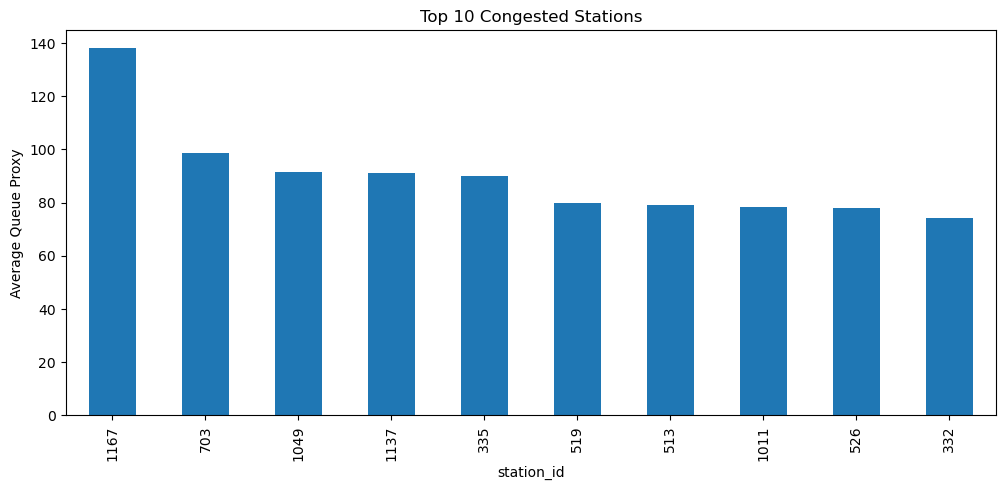

In [16]:
top_stations = (
    master.groupby("station_id")
    ["queue_proxy"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
top_stations.plot(kind="bar")

plt.title("Top 10 Congested Stations")
plt.ylabel("Average Queue Proxy")
plt.show()

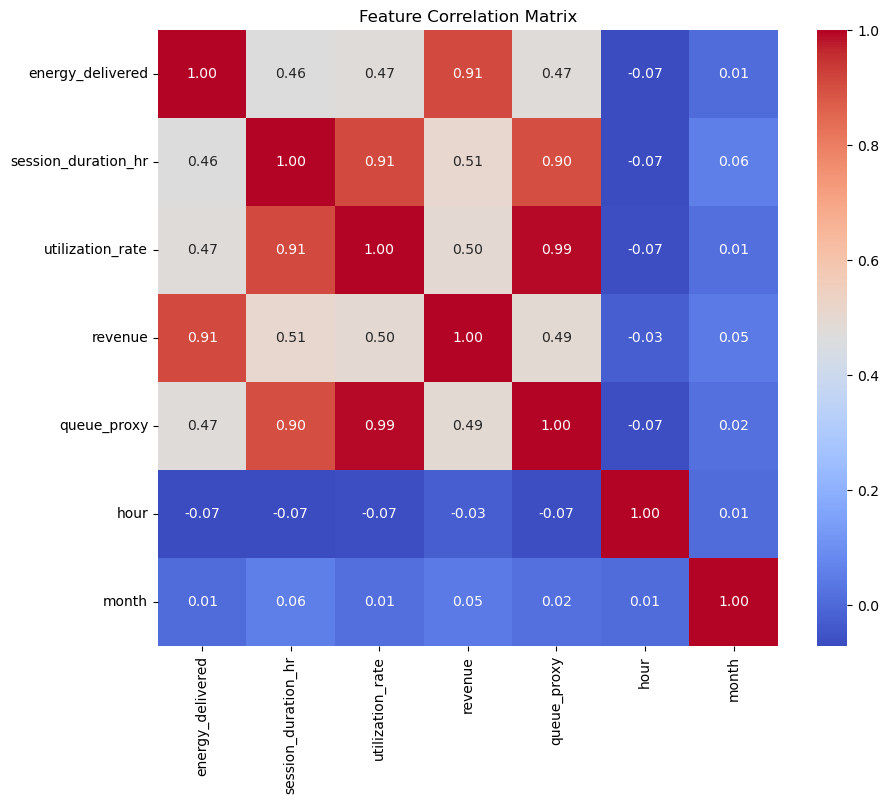

In [17]:
corr_features = [
    "energy_delivered",
    "session_duration_hr",
    "utilization_rate",
    "revenue",
    "queue_proxy",
    "hour",
    "month"
]

corr = master[corr_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()